In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score

from dataset.pairs.bin_reader import FacePairBinReader
from dataset.pairs.bin_visualizer import FacePairVisualizer
from utils.config_loader import Config
from utils.paths import ProjectPathResolver

In [2]:
config_fpe = Config(path="config.fc_pair_eval.yaml")
path_resolver_fpe = ProjectPathResolver(config_fpe)

output_dir = path_resolver_fpe["paths.results_dir"]
os.makedirs(output_dir, exist_ok=True)
PLOTS_DIR = path_resolver_fpe["paths.plot_dir"]
PAIR_IMAGES_DIR = path_resolver_fpe["paths.pair_images_dir"]

In [3]:
reader = FacePairBinReader(path_resolver_fpe['paths.bin_subset'].path)
pairs = reader.load_pil_pairs()

In [4]:
df_committee_fcw112 = pd.read_csv(output_dir / "pair-gt_labat-cropped_image-warpe-112x112-len1180" / "committee_full_analysis.csv")
df_committee_ffidr = pd.read_csv(output_dir / "pair-gt_labat-full_image-default_480x640-len1180" / "committee_full_analysis.csv")

In [5]:
df_committee_fcw112

,pair_id,ground_truth_fraude,pred_gemini,pred_chatgpt,pred_claude,justificativa_gemini,justificativa_chatgpt,justificativa_claude,similaridade_gemini,similaridade_chatgpt,...,gemini_output_tokens,gemini_total_tokens,chatgpt_tempo_inferencia_s,chatgpt_input_tokens,chatgpt_output_tokens,chatgpt_total_tokens,claude_tempo_inferencia_s,claude_input_tokens,claude_output_tokens,claude_total_tokens
0,0,False,False,False,False,"Os traços faciais, incluindo formato do nariz,...",Traços faciais e características semelhantes.,Traços faciais correspondentes: formato do ros...,0.92,0.82,...,67,1236,3.1218,6219,33,6252,1.9203,360,62,422
1,1,False,False,False,False,"Traços faciais como formato do nariz, olhos, b...",Traços faciais e estrutura semelhantes.,Traços faciais correspondentes: formato do ros...,0.92,0.82,...,63,1239,1.4325,6219,33,6252,1.4935,360,63,423
2,2,False,False,True,True,"Traços faciais como barba, bigode, formato do ...",Diferenças na iluminação e ângulo afetam a com...,Características faciais distintas. Formato do ...,0.92,0.65,...,64,1369,1.5288,6219,38,6257,1.6270,360,65,425
3,3,False,False,False,False,"Traços faciais como formato do rosto, nariz, b...",Traços faciais e estrutura do rosto são muito ...,Traços faciais correspondentes: formato do ros...,0.92,0.82,...,62,1419,1.4655,6219,37,6256,1.4101,360,59,419
4,4,False,False,True,False,"Traços faciais, formato do nariz, barba e bigo...",Diferenças notáveis na estrutura facial e no f...,Traços faciais correspondentes: formato do ros...,0.91,0.65,...,66,1485,1.3526,6219,40,6259,1.2600,360,61,421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1175,1175,True,True,True,False,"Formatos do rosto, nariz e presença de barba s...",Características faciais e acessórios diferentes,Traços faciais correspondentes: formato do ros...,0.10,0.25,...,58,1294,1.4791,6219,32,6251,1.2394,360,62,422
1176,1176,True,True,True,False,"Diferenças claras na estrutura facial, formato...",Características faciais completamente diferentes.,Traços faciais correspondentes: formato do ros...,0.20,0.10,...,57,1288,1.1000,6219,31,6250,1.2428,360,67,427
1177,1177,True,True,True,False,"Gênero, presença de barba e bigode, e estrutur...","Imagens mostram pessoas diferentes, traços fac...",Traços faciais correspondentes: formato do ros...,0.05,0.10,...,61,1156,0.9527,6219,39,6258,1.2663,360,59,419
1178,1178,True,True,True,True,As imagens mostram pessoas de gêneros diferent...,"Imagens de pessoas diferentes, traços faciais ...","Estrutura facial, formato do nariz e caracterí...",0.01,0.00,...,62,1267,1.9206,6219,39,6258,1.2661,360,58,418


In [4]:
# --- 1. CARREGAR OS DADOS ---
# Ajuste o caminho se o seu output_dir for diferente
print("Carregando resultados dos 3 modelos...")

df_gemini = pd.read_csv(output_dir / "gemini_gt-labat_warpe_with_pivot_final_evaluation.csv").set_index('pair_id')
df_chatgpt = pd.read_csv(output_dir/ "chatgpt_gt-labat_warpe_with_pivot_final_evaluation.csv").set_index('pair_id')
df_claude = pd.read_csv(output_dir / "anthropic_gt-labat_warpe_with_pivot_final_evaluation.csv").set_index('pair_id')

Carregando resultados dos 3 modelos...


In [5]:
# --- 2. CONSTRUIR O DATAFRAME DO COMITÊ ---
# Vamos usar o Gemini como base para o Ground Truth
df_comite = pd.DataFrame(index=df_gemini.index)
df_comite['ground_truth_fraude'] = ~df_gemini['ground_truth_is_same']

# Pegamos apenas as predições booleanas de cada modelo
df_comite['pred_gemini'] = df_gemini['pred_fraude'].astype(bool)
df_comite['pred_chatgpt'] = df_chatgpt['pred_fraude'].astype(bool)
df_comite['pred_claude'] = df_claude['pred_fraude'].astype(bool)

# Pegamos as justificativas para análise manual posterior
df_comite['justificativa_gemini'] = df_gemini['justificativa']
df_comite['justificativa_chatgpt'] = df_chatgpt['justificativa']
df_comite['justificativa_claude'] = df_claude['justificativa']

df_comite['tempo_inferencia_s_gemini'] = df_gemini['tempo_inferencia_s']
df_comite['tempo_inferencia_s_chatgpt'] = df_chatgpt['tempo_inferencia_s']
df_comite['tempo_inferencia_s_claude'] = df_claude['tempo_inferencia_s']

In [6]:
# --- 3. LÓGICA DO COMITÊ (ENSEMBLE) ---
# Soma dos votos de fraude (0 = Todos dizem genuíno, 3 = Todos dizem fraude)
df_comite['soma_votos_fraude'] = df_comite[['pred_gemini', 'pred_chatgpt', 'pred_claude']].sum(axis=1)

# Voto da Maioria (Maior ou igual a 2 significa que a maioria achou que é fraude)
df_comite['pred_maioria'] = df_comite['soma_votos_fraude'] >= 2

# Nível de Concordância
df_comite['unanimidade'] = (df_comite['soma_votos_fraude'] == 0) | (df_comite['soma_votos_fraude'] == 3)
df_comite['divergencia'] = ~df_comite['unanimidade']

In [7]:
# --- 4. CÁLCULO DE ACERTOS ---
df_comite['gemini_acertou'] = df_comite['pred_gemini'] == df_comite['ground_truth_fraude']
df_comite['chatgpt_acertou'] = df_comite['pred_chatgpt'] == df_comite['ground_truth_fraude']
df_comite['claude_acertou'] = df_comite['pred_claude'] == df_comite['ground_truth_fraude']
df_comite['comite_acertou'] = df_comite['pred_maioria'] == df_comite['ground_truth_fraude']

In [8]:
df_comite.head(20)

,ground_truth_fraude,pred_gemini,pred_chatgpt,pred_claude,justificativa_gemini,justificativa_chatgpt,justificativa_claude,soma_votos_fraude,pred_maioria,unanimidade,divergencia,gemini_acertou,chatgpt_acertou,claude_acertou,comite_acertou
pair_id,,,,,,,,,,,,,,,
0,False,False,False,False,"Os traços faciais, incluindo formato do nariz,...",Traços faciais e características são muito sem...,Traços faciais correspondentes. Estrutura ósse...,0,False,True,False,True,True,True,True
1,False,True,True,True,"A segunda imagem é escura demais, impossibilit...",Imagens de baixa qualidade dificultam a compar...,Qualidade de imagem insuficiente. Segunda imag...,3,True,True,False,False,False,False,False
2,False,True,True,True,"A segunda imagem é excessivamente escura, impo...",Imagens de baixa qualidade dificultam a compar...,Imagens com qualidade muito baixa. Impossível ...,3,True,True,False,False,False,False,False
3,False,False,False,False,"Traços faciais como formato do rosto, nariz e ...",Traços faciais e características são muito sem...,Traços faciais correspondentes: formato do ros...,0,False,True,False,True,True,True,True
4,False,False,True,False,"Traços faciais como formato dos lábios, sobran...",Diferenças notáveis na expressão facial e ângu...,Traços faciais correspondentes: formato do ros...,1,False,False,True,True,False,True,True
5,False,False,False,False,"Traços faciais como nariz, boca e formato do r...",Traços faciais e estrutura óssea são consisten...,Traços faciais correspondentes: formato do ros...,0,False,True,False,True,True,True,True
6,False,False,False,False,"Os traços faciais, incluindo formato do nariz ...",Traços faciais e estrutura óssea são muito sem...,Traços faciais correspondentes: formato do ros...,0,False,True,False,True,True,True,True
7,False,False,False,True,Apesar dos óculos escuros e ângulos diferentes...,Traços faciais e formato do rosto são consiste...,"Estrutura facial, formato do nariz e contorno ...",1,False,False,True,True,True,False,True
8,False,False,False,False,"Traços faciais visíveis, como formato do nariz...",Traços faciais e estrutura óssea são muito sem...,Traços faciais correspondentes: formato do ros...,0,False,True,False,True,True,True,True


In [36]:
filter_committee = df_comite[
    (df_comite['unanimidade']) &
    (df_comite['soma_votos_fraude'] == 3) &
    (df_comite['ground_truth_fraude'] == False)
    ]

list_filtered_pair_id = filter_committee.index.tolist()

print(f"Lista de Predições de fraudes quando não fraude. Quantidade: {len(list_filtered_pair_id)}\nLista: {list_filtered_pair_id}")


Lista de Predições de fraudes quando não fraude. Quantidade: 59
Lista: [1, 2, 9, 15, 16, 18, 20, 25, 26, 69, 78, 79, 105, 106, 110, 112, 115, 118, 139, 145, 149, 150, 158, 159, 160, 162, 165, 181, 182, 185, 187, 194, 196, 199, 204, 208, 219, 234, 237, 238, 251, 253, 256, 258, 259, 260, 262, 263, 266, 268, 276, 277, 278, 282, 293, 294, 295, 322, 324]


In [ ]:
filter_committee.head(20)

In [ ]:
# --- Construção da Tabela de Resultados ---
df_comite

In [12]:
# --- 5. RESUMO DE ACURÁCIA ---
acc_gemini = accuracy_score(df_comite['ground_truth_fraude'], df_comite['pred_gemini'])
acc_chatgpt = accuracy_score(df_comite['ground_truth_fraude'], df_comite['pred_chatgpt'])
acc_claude = accuracy_score(df_comite['ground_truth_fraude'], df_comite['pred_claude'])
acc_comite = accuracy_score(df_comite['ground_truth_fraude'], df_comite['pred_maioria'])

print("\n--- ACURÁCIA DOS MODELOS ---")
print(f"1. Gemini 2.5 Flash: {acc_gemini:.2%}")
print(f"2. ChatGPT (4o-mini): {acc_chatgpt:.2%}")
print(f"3. Claude 3.5 Haiku: {acc_claude:.2%}")
print(f" COMITÊ (Voto da Maioria): {acc_comite:.2%}")

print("\n--- ANÁLISE DE CONCORDÂNCIA ---")
total_pares = len(df_comite)
unanimes = df_comite['unanimidade'].sum()
divergentes = df_comite['divergencia'].sum()
unanimes_errados = len(df_comite[(df_comite['unanimidade'] == True) & (df_comite['comite_acertou'] == False)])

print(f"Decisões Unânimes: {unanimes}/{total_pares} ({unanimes/total_pares:.2%})")
print(f"Decisões Divergentes (2 vs 1): {divergentes}/{total_pares} ({divergentes/total_pares:.2%})")
print(f"Alucinação Coletiva (Todos erraram juntos): {unanimes_errados}/{total_pares}")


--- ACURÁCIA DOS MODELOS ---
1. Gemini 2.5 Flash: 77.82%
2. ChatGPT (4o-mini): 76.01%
3. Claude 3.5 Haiku: 62.10%
 COMITÊ (Voto da Maioria): 74.80%

--- ANÁLISE DE CONCORDÂNCIA ---
Decisões Unânimes: 322/496 (64.92%)
Decisões Divergentes (2 vs 1): 174/496 (35.08%)
Alucinação Coletiva (Todos erraram juntos): 59/496


/tmp/ipykernel_904272/1627821855.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelos, y=acuracias, palette=cores, ax=axes[0])


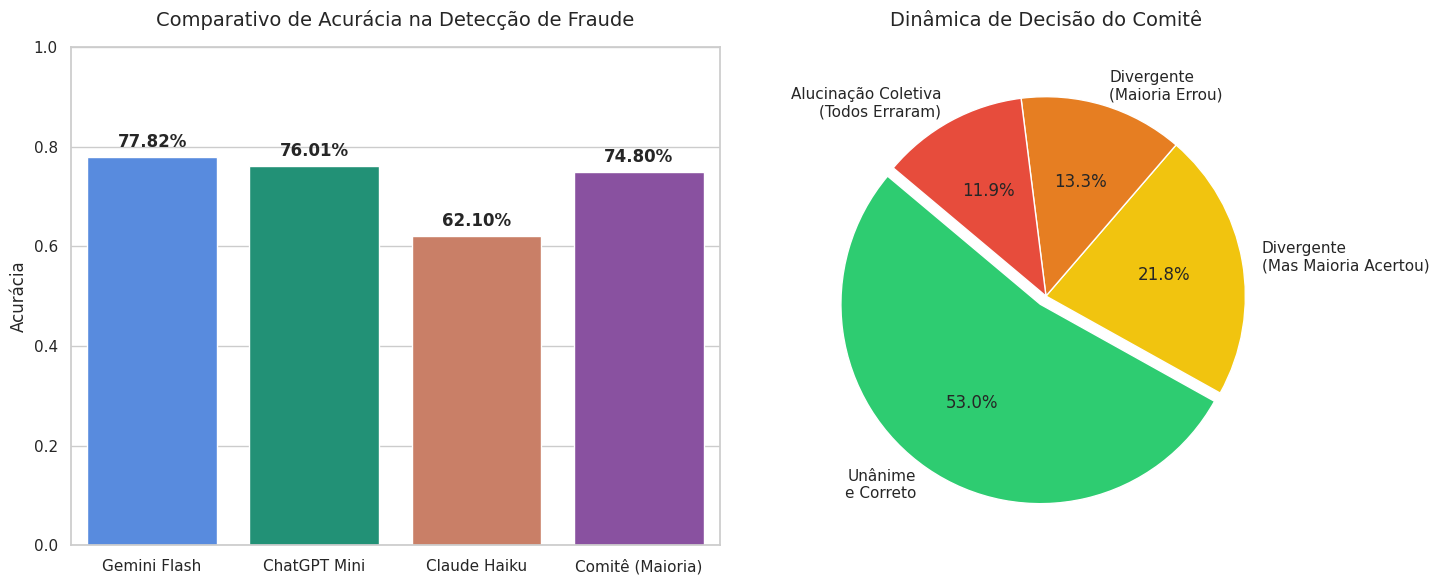

In [10]:
# --- 6. GRÁFICOS PARA O ARTIGO ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Comparativo de Acurácia
modelos = ['Gemini Flash', 'ChatGPT Mini', 'Claude Haiku', 'Comitê (Maioria)']
acuracias = [acc_gemini, acc_chatgpt, acc_claude, acc_comite]
cores = ['#4285F4', '#10a37f', '#d97757', '#8e44ad'] # Cores das marcas + roxo pro comitê

sns.barplot(x=modelos, y=acuracias, palette=cores, ax=axes[0])
axes[0].set_title('Comparativo de Acurácia na Detecção de Fraude', fontsize=14, pad=15)
axes[0].set_ylabel('Acurácia')
axes[0].set_ylim(0, 1.0)
for i, v in enumerate(acuracias):
    axes[0].text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

# Gráfico 2: Composição da Concordância
pizza_labels = ['Unânime\ne Correto', 'Divergente\n(Mas Maioria Acertou)', 'Divergente\n(Maioria Errou)', 'Alucinação Coletiva\n(Todos Erraram)']
pizza_sizes = [
    len(df_comite[(df_comite['unanimidade'] == True) & (df_comite['comite_acertou'] == True)]),
    len(df_comite[(df_comite['divergencia'] == True) & (df_comite['comite_acertou'] == True)]),
    len(df_comite[(df_comite['divergencia'] == True) & (df_comite['comite_acertou'] == False)]),
    unanimes_errados
]
pizza_cores = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

axes[1].pie(pizza_sizes, labels=pizza_labels, autopct='%1.1f%%', startangle=140, colors=pizza_cores, explode=(0.05, 0, 0, 0))
axes[1].set_title('Dinâmica de Decisão do Comitê', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

In [ ]:
# --- 7. EXPORTAÇÃO DOS CASOS POLÊMICOS ---
# Salva um CSV apenas com os casos onde houve divergência ou erro unânime para você auditar visualmente
df_polemicos = df_comite[df_comite['comite_acertou'] == False | df_comite['divergencia'] == True]
df_polemicos.to_csv(f"{output_dir}/analise_casos_polemicos.csv")
print(f"\nSalvo arquivo 'analise_casos_polemicos.csv' com {len(df_polemicos)} casos difíceis para inspeção visual.")

In [ ]:
visualizer = FacePairVisualizer(bin_reader=reader, directory=PAIR_IMAGES_DIR, save_image=True)
hard_cases = [1, 2, 3, 5, 9, 16, 25, 26, 28, 29, 38, 41, 53]
visualizer.show_by_list(list_filtered_pair_id)
#false_positive_pairs_ids = df_plot[df_plot['Acertou'] == False]['pair_id']
#visualizer.show_by_list(false_positive_pairs_ids)